# RQ4 — Operational Comparison: AI Models vs. Rule-Based Fraud Detection

Chapter 2's literature review makes a specific claim: rule-based systems are
static, threshold-driven, and generate a heavy false-positive burden compared
to AI-based detection. This notebook builds an actual rule-based system to
test that claim directly, rather than only citing it.

**A structural limitation worth stating upfront:** the Credit Card dataset
exposes only `Time` and `Amount` as raw, human-interpretable fields (V1-V28
are anonymized PCA components no analyst would hand-write a threshold on),
and critically, it has **no account, card, or merchant identifier**. Real
bank rule engines lean heavily on **velocity rules** ("5+ transactions in 10
minutes on the same card") and **geographic rules** ("purchase 800km from the
previous one within an hour") - neither is computable here, because there is
no field to group transactions by the same customer or card. This is a
genuine dataset limitation, not a modeling choice, and it is noted explicitly
in Chapter 5 (Limitations) rather than glossed over.

**What this notebook does instead:** it builds every rule that *is* honestly
computable from `Time` and `Amount` alone - the kind of point-based rule
engine a bank would actually run before/alongside a card-identifier-aware
system - and compares the whole rule engine against the AI models from
Section 4.2.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix,
)
import xgboost as xgb

sns.set_theme(style="whitegrid")

## 0.1 Config

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Bicocca/Thesis code')
DATA_PATH = BASE / 'data' / 'raw' / 'creditcard.csv'
OUTDIR = BASE / 'results' / 'credit_card'
FIGDIR = OUTDIR / 'figures'
for p in [OUTDIR, FIGDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Looking for data at:', DATA_PATH)
print('Exists:', DATA_PATH.exists())

Mounted at /content/drive
Looking for data at: /content/drive/MyDrive/Bicocca/Thesis code/data/raw/creditcard.csv
Exists: True


## 1. Load + chronological split

Identical split to the main experiment (70/10/20 by `Time`), so results are
directly comparable to Table 4.1.

In [3]:
df = pd.read_csv(DATA_PATH).sort_values("Time").reset_index(drop=True)

n = len(df)
n_test = int(n * 0.2)
n_val = int(n * 0.1)
n_train = n - n_test - n_val

train = df.iloc[:n_train]
test = df.iloc[n_train + n_val:]

print(f"Train: {len(train):,} ({train['Class'].mean()*100:.3f}% fraud)")
print(f"Test:  {len(test):,} ({test['Class'].mean()*100:.3f}% fraud)")

Train: 199,366 (0.193% fraud)
Test:  56,961 (0.132% fraud)


## 2. Individual rules

Each rule is calibrated on the **training set only**. Five rules, each one a
real heuristic used in practice:

1. **High amount** - above the 99th percentile of training amounts. The
   single most common manual fraud rule.
2. **Unusual hour** - occurs between 2am-5am (derived from `Time` modulo 24h),
   a standard "off-hours activity" heuristic.
3. **Round amount** - the amount is suspiciously "clean" (an exact multiple
   of 10, e.g. $50.00, $100.00). Fraudsters testing a stolen card, and some
   automated fraud scripts, disproportionately use round test amounts.
4. **Micro-transaction ("card testing")** - below the 1st percentile of
   training amounts. Small, easy-to-miss charges are a classic way fraudsters
   verify a stolen card works before attempting a larger purchase.
5. **Statistical control limit** - amount exceeds the training mean plus
   three standard deviations, a classic statistical process-control rule used
   in some legacy AML/fraud systems. Because `Amount` is heavily right-skewed,
   this behaves very differently from the percentile-based Rule 1, which is
   itself an illustration of how sensitive simple threshold rules are to the
   (often wrong) assumption of a roughly normal distribution.

In [4]:
def hour_of_day(t):
    return (t % 86400) / 3600.0

amount_p99 = train["Amount"].quantile(0.99)
amount_p01 = train["Amount"].quantile(0.01)
amount_mean, amount_std = train["Amount"].mean(), train["Amount"].std()
control_limit = amount_mean + 3 * amount_std

print(f"Rule 1 - high amount threshold (99th pct):      ${amount_p99:.2f}")
print(f"Rule 3 - round-amount check: exact multiples of 10")
print(f"Rule 4 - micro-transaction threshold (1st pct):  ${amount_p01:.2f}")
print(f"Rule 5 - statistical control limit (mean+3sd):   ${control_limit:.2f}")

test_hours = hour_of_day(test["Time"])

rules_test = pd.DataFrame({
    "rule_1_high_amount": (test["Amount"] > amount_p99).astype(int),
    "rule_2_unusual_hour": ((test_hours >= 2) & (test_hours < 5)).astype(int),
    "rule_3_round_amount": (np.abs(test["Amount"] % 10) < 0.01).astype(int),
    "rule_4_micro_txn": (test["Amount"] < amount_p01).astype(int),
    "rule_5_control_limit": (test["Amount"] > control_limit).astype(int),
})

print("\nHow often each rule fires on the test set:")
print(rules_test.mean().round(4).rename("fraction flagged"))

Rule 1 - high amount threshold (99th pct):      $1030.87
Rule 3 - round-amount check: exact multiples of 10
Rule 4 - micro-transaction threshold (1st pct):  $0.02
Rule 5 - statistical control limit (mean+3sd):   $836.50

How often each rule fires on the test set:
rule_1_high_amount      0.0084
rule_2_unusual_hour     0.0000
rule_3_round_amount     0.0605
rule_4_micro_txn        0.0062
rule_5_control_limit    0.0123
Name: fraction flagged, dtype: float64


## 3. Weighted rule engine (the realistic bank system)

Real fraud rule engines rarely act on a single rule in isolation - they
assign each rule a weight ("risk points") and flag a transaction once its
total score crosses a threshold. Weights below are illustrative but ordered
the way a fraud team would order them: a high amount is a much stronger
individual signal than an off-hours timestamp.

| Rule | Points |
|---|---|
| High amount | 3 |
| Statistical control limit | 2 |
| Micro-transaction | 2 |
| Round amount | 1 |
| Unusual hour | 1 |

A transaction is flagged if its total score is **3 or higher** (i.e. the high
-amount rule alone is already enough, or any two of the weaker signals
together).

In [5]:
weights = {
    "rule_1_high_amount": 3,
    "rule_5_control_limit": 2,
    "rule_4_micro_txn": 2,
    "rule_3_round_amount": 1,
    "rule_2_unusual_hour": 1,
}

risk_score = sum(rules_test[col] * w for col, w in weights.items())
FLAG_THRESHOLD = 3
engine_flag = (risk_score >= FLAG_THRESHOLD).astype(int)

print(f"Weighted engine flags {engine_flag.sum():,} of {len(test):,} transactions "
      f"({engine_flag.mean()*100:.2f}%)")
print("\nRisk score distribution:")
print(risk_score.value_counts().sort_index())

Weighted engine flags 779 of 56,961 transactions (1.37%)

Risk score distribution:
0    52803
1     3103
2      276
3      303
5      438
6       38
Name: count, dtype: int64


## 4. Evaluate every individual rule and the combined engine

For AUC-style metrics, each rule needs a continuous score, not just a 0/1
flag. For the amount-based rules we use the underlying continuous quantity
itself (`Amount`, possibly sign-flipped) as the score; for the two rules with
no natural continuous version of their own (unusual hour, round amount) we
fall back to the combined weighted risk score.

In [6]:
def evaluate(y_true, y_pred, y_score):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

y_test = test["Class"]
rule_results = []

rule_scores_for_auc = {
    "rule_1_high_amount": test["Amount"],
    "rule_2_unusual_hour": risk_score,
    "rule_3_round_amount": risk_score,
    "rule_4_micro_txn": -test["Amount"],   # smaller amount = higher risk for this rule specifically
    "rule_5_control_limit": test["Amount"],
}

rule_labels = {
    "rule_1_high_amount": "Rule 1: High amount",
    "rule_2_unusual_hour": "Rule 2: Unusual hour",
    "rule_3_round_amount": "Rule 3: Round amount",
    "rule_4_micro_txn": "Rule 4: Micro-transaction",
    "rule_5_control_limit": "Rule 5: Control limit (mean+3sd)",
}

for col, label in rule_labels.items():
    t0 = time.time()
    m = evaluate(y_test, rules_test[col], rule_scores_for_auc[col])
    latency = (time.time() - t0) * 1000 / len(test)
    m.update({"system": label, "latency_ms_per_sample": latency, "n_flagged": int(rules_test[col].sum())})
    rule_results.append(m)

t0 = time.time()
m_engine = evaluate(y_test, engine_flag, risk_score)
latency_engine = (time.time() - t0) * 1000 / len(test)
m_engine.update({"system": "Weighted rule engine (all 5 rules)",
                  "latency_ms_per_sample": latency_engine, "n_flagged": int(engine_flag.sum())})
rule_results.append(m_engine)

pd.DataFrame(rule_results).round(4)

,precision,recall,f1,pr_auc,roc_auc,system,latency_ms_per_sample,n_flagged
0,0.0042,0.0267,0.0073,0.0014,0.3820,Rule 1: High amount,0.0010,476
1,0.0000,0.0000,0.0000,0.0021,0.5397,Rule 2: Unusual hour,0.0007,0
2,0.0020,0.0933,0.0040,0.0021,0.5397,Rule 3: Round amount,0.0006,3444
3,0.0170,0.0800,0.0281,0.0052,0.6180,Rule 4: Micro-transaction,0.0008,352
4,0.0043,0.0400,0.0077,0.0014,0.3820,Rule 5: Control limit (mean+3sd),0.0007,703
5,0.0090,0.0933,0.0164,0.0021,0.5397,Weighted rule engine (all 5 rules),0.0005,779


## 5. Train a representative AI model for direct comparison

XGBoost with no resampling - the fastest configuration from Section 4.4,
retrained fresh here so this notebook runs standalone.

In [7]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in train.columns if c != "Class"]
scaler = StandardScaler()
train_s, test_s = train.copy(), test.copy()
for col in ["Time", "Amount"]:
    train_s[col] = scaler.fit_transform(train[[col]])
    test_s[col] = scaler.transform(test[[col]])

X_train, y_train = train_s[feature_cols], train_s["Class"]
X_test = test_s[feature_cols]

t0 = time.time()
model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric="aucpr", random_state=42, n_jobs=-1,
)
model.fit(X_train, y_train)
train_time_s = time.time() - t0

t1 = time.time()
y_pred_ml = model.predict(X_test)
y_score_ml = model.predict_proba(X_test)[:, 1]
latency_ml = (time.time() - t1) * 1000 / len(X_test)

metrics_ml = evaluate(y_test, y_pred_ml, y_score_ml)
metrics_ml.update({
    "system": "XGBoost (no resampling)",
    "latency_ms_per_sample": latency_ml,
    "n_flagged": int(y_pred_ml.sum()),
    "train_time_s": train_time_s,
})
print(metrics_ml)

{'precision': 0.9574468085106383, 'recall': 0.6, 'f1': 0.7377049180327869, 'pr_auc': np.float64(0.7326265731865587), 'roc_auc': np.float64(0.98265935379531), 'system': 'XGBoost (no resampling)', 'latency_ms_per_sample': 0.011211658691485544, 'n_flagged': 47, 'train_time_s': 25.500267267227173}


## 6. Full comparison: 5 individual rules + weighted engine + AI model

In [8]:
comparison_df = pd.DataFrame(rule_results + [metrics_ml])
comparison_df = comparison_df[["system", "precision", "recall", "f1", "pr_auc", "roc_auc",
                                "n_flagged", "latency_ms_per_sample"]]
comparison_df.to_csv(OUTDIR / "rq4_rule_vs_ai_comparison.csv", index=False)
comparison_df.round(4)

,system,precision,recall,f1,pr_auc,roc_auc,n_flagged,latency_ms_per_sample
0,Rule 1: High amount,0.0042,0.0267,0.0073,0.0014,0.3820,476,0.0010
1,Rule 2: Unusual hour,0.0000,0.0000,0.0000,0.0021,0.5397,0,0.0007
2,Rule 3: Round amount,0.0020,0.0933,0.0040,0.0021,0.5397,3444,0.0006
3,Rule 4: Micro-transaction,0.0170,0.0800,0.0281,0.0052,0.6180,352,0.0008
4,Rule 5: Control limit (mean+3sd),0.0043,0.0400,0.0077,0.0014,0.3820,703,0.0007
5,Weighted rule engine (all 5 rules),0.0090,0.0933,0.0164,0.0021,0.5397,779,0.0005
6,XGBoost (no resampling),0.9574,0.6000,0.7377,0.7326,0.9827,47,0.0112


/tmp/ipykernel_2666/400141874.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right", fontsize=8)


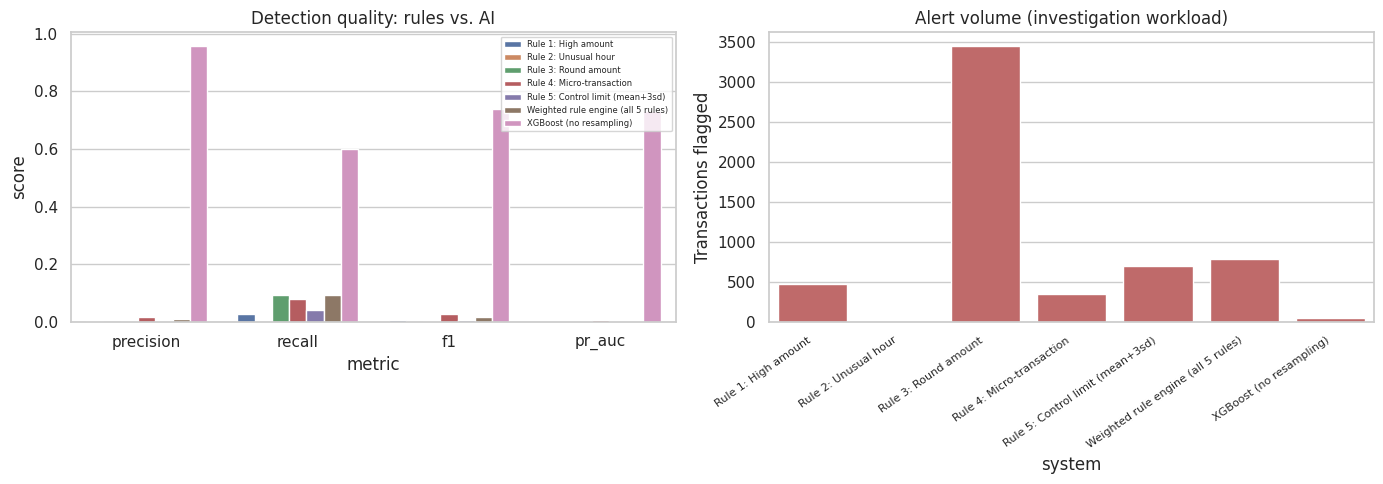

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = comparison_df.melt(id_vars="system", value_vars=["precision", "recall", "f1", "pr_auc"],
                              var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="metric", y="score", hue="system", ax=axes[0])
axes[0].set_title("Detection quality: rules vs. AI")
axes[0].legend(fontsize=6, loc="upper right", ncol=1)
axes[0].tick_params(axis="x", rotation=0)

sns.barplot(data=comparison_df, x="system", y="n_flagged", ax=axes[1], color="indianred")
axes[1].set_title("Alert volume (investigation workload)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Transactions flagged")

plt.tight_layout()
plt.savefig(FIGDIR / "rq4_rule_vs_ai.png", dpi=150)
plt.show()

## 7. Investigation-burden framing

Converts the table into the language a compliance team actually thinks in:
how many alerts, how many are real, how much of the fraud is caught.

In [10]:
n_fraud_test = int(y_test.sum())

for row in comparison_df.to_dict("records"):
    n_flagged = row["n_flagged"]
    n_caught = round(row["recall"] * n_fraud_test)
    precision_pct = row["precision"] * 100
    print(f"{row['system']}:")
    print(f"  Flags {n_flagged:,} transactions to catch {n_caught} of {n_fraud_test} fraud cases "
          f"({row['recall']*100:.1f}% recall)")
    print(f"  Of every 100 alerts raised, ~{precision_pct:.1f} are actually fraud "
          f"(the rest are investigator time spent on false alarms)")
    print()

Rule 1: High amount:
  Flags 476 transactions to catch 2 of 75 fraud cases (2.7% recall)
  Of every 100 alerts raised, ~0.4 are actually fraud (the rest are investigator time spent on false alarms)

Rule 2: Unusual hour:
  Flags 0 transactions to catch 0 of 75 fraud cases (0.0% recall)
  Of every 100 alerts raised, ~0.0 are actually fraud (the rest are investigator time spent on false alarms)

Rule 3: Round amount:
  Flags 3,444 transactions to catch 7 of 75 fraud cases (9.3% recall)
  Of every 100 alerts raised, ~0.2 are actually fraud (the rest are investigator time spent on false alarms)

Rule 4: Micro-transaction:
  Flags 352 transactions to catch 6 of 75 fraud cases (8.0% recall)
  Of every 100 alerts raised, ~1.7 are actually fraud (the rest are investigator time spent on false alarms)

Rule 5: Control limit (mean+3sd):
  Flags 703 transactions to catch 3 of 75 fraud cases (4.0% recall)
  Of every 100 alerts raised, ~0.4 are actually fraud (the rest are investigator time spent on